# **Notebook 3: Modelling**

> **Objective:** Apply clustering alogrithms to our processed customer dataset `clean_customer_info` in order to find meaningful customer segments to, then, allow the creation of association rules and targeted promotions across the different segments. This notebook functions are defined in the `clustering.py` script.


---

## **Table of Contents**
1. Imports and Libraries
2. Load Raw Datasets
3. Execute Independent Cleaning Pipelines
4. Merging the Two Clean Datasets (Inner Join)
5. Validation Checks
6. Export Final Data

---

## **1. Imports and Data Loading**

In [1]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import confusion_matrix, adjusted_rand_score


from utils import (
    scaling,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette_kmeans,
    plot_silhouette_hierarchical,
    plot_elbow,
    print_silhouette_scores,
    apply_kmeans_perc,
    apply_kmeans_lifetime,
    apply_hierarchical_perc,
    apply_hierarchical_lifetime,
    cluster_groupby,
    dendrogram_visualization
)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,year_first_transaction,distinct_stores_visited,number_complaints,typical_hour,...,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2020,3,1,10,...,0.020065,0.012964,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0
4,Glenda Bauman,female,51,Bsc,1,0,2013,2,0,10,...,0.099442,0.002867,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0
5,Antonio Campbell,male,55,Msc,0,0,2005,2,1,11,...,0.035694,0.098913,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0
7,John Kelling,male,44,Unknown,0,0,2021,1,2,18,...,0.005618,0.137440,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0
8,Arthur Dematteo,male,57,Unknown,0,0,2021,1,3,17,...,0.014730,0.080746,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0


## **2. Dense region on the geographical map**

From the EDA notebook we could observe that the dense region on the map is not noise, instead it is probably a segment of customers with similar spending behavior or characteristics.

In [3]:
min_lat = 38.7468
max_lat = 38.7488

min_lon = -9.1576
max_lon = -9.1556


dataset['is_dense_geo_area'] = (
    dataset['longitude'].between(min_lon, max_lon) &
    dataset['latitude'].between(min_lat, max_lat)
).astype(int)

dataset['is_dense_geo_area'].value_counts()

is_dense_geo_area
0    30623
1     2415
Name: count, dtype: int64

In [4]:
geo_profile = dataset.groupby('is_dense_geo_area')[
    [
        'customer_age',
        'number_complaints',
        'kids_home',
        'teens_home',
        'percentage_of_products_bought_promotion',


        'lifetime_spend_vegetables',
        'lifetime_spend_meat_fish',
        'lifetime_spend_electronics',
        'lifetime_spend_videogames',
        'lifetime_spend_hygiene',
        'lifetime_spend_alcohol_drinks',
    ]
].mean().T

geo_profile

is_dense_geo_area,0,1
customer_age,56.869053,32.655072
number_complaints,0.842112,2.063768
kids_home,1.044182,2.030228
teens_home,0.925905,0.559006
percentage_of_products_bought_promotion,0.308009,0.501721
lifetime_spend_vegetables,751.870555,215.649275
lifetime_spend_meat_fish,1329.799889,918.877019
lifetime_spend_electronics,2846.105542,954.018219
lifetime_spend_videogames,384.795481,133.415321
lifetime_spend_hygiene,844.432061,402.836025


As we can observe, the customers from the dense geographic region are much more younger, with a high number of complaints, more kids at home, but less teens home, indicating young parents.
Regarding the spending behavior, customers of this area show lower average spending across all categories, except on `lifetime_spend_alcohol_drinks` and on `percentage_of_products_bought_promotion`, which makes sense as most of young adults earn less, therefore spend less and take advantage of promotions more often than older customers.

Therefore, these customers are separated before applying K-Means and are directly assigned to their own cluster, which will be done in the end of the notebook. We are going to separate `dataset` into two different datasets, the one containing the customers from the dense region and the other for the remaining customers, on which we will perform the **segmentation process**. 


In [5]:
geo_cluster_df = dataset[dataset['is_dense_geo_area'] == 1].copy()
modelling_df = dataset[dataset['is_dense_geo_area'] == 0].copy()

## **2. Clustering with Percentages**

### **2.1. Feature Selection and Pre-Processing**

Regarding the features we used for the clustering, after **several tries with different combinations**, we ended up choosing the ones in the cell below. 

This section contemplates both demographic variables (`customer_age`, `total_children`, `years_tenure`) and behavioral metrics (`spend percentages`, `number_complaints`, `percentage_of_products_bought_promotion`). This approach allows the K-Means algorithm to capture and differentiate customers with similar shopping tendencies but with different life stages. 

##### **2.1.1 'Lifetime Spend' vs Percentage Spend**
A critical data engineering decision was to utilize relative **percentage spending instead of absolute lifetime spend** metrics (e.g., using perc_spend_vegetables rather than lifetime_spend_vegetables).

If absolute values had been used, the K-Means would be biased by overall purchasing power, simply dividing the database into "Rich Customers" vs. "Poor Customers". By converting the data into percentages, we "normalize" the shopping basket. This forces the algorithm to group customers based on their lifestyle preferences and tastes (e.g., identifying a strict Vegetarian), regardless of whether their total budget is large or small. 

##### **2.1.2 Removing Uninformative Categories**

Some features were purposely **excluded** from the final feature selection like, the groceries, pet food and alcohol. After several tries to improve our clustering, these variables showed **low variance or no pattern across our customers**. They would act more as statistical **noise** rather than differentiating factors, that way, the algortihm only focuses on the features that truly segmentate our customers.


Geospatial variables (latitude, longitude) were also **excluded** to prevent the model from creating regional bias, reserving them for later profiling.

In [7]:
dataset_perc = modelling_df.copy()

dataset_perc.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'year_first_transaction',
       'distinct_stores_visited', 'number_complaints', 'typical_hour',
       'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_outlier', 'is_dense_geo_area'],
    

For the percentage-based model, we selected demographic variables, promotion sensitivity, complaints, and relative spending proportions.

In [ ]:
features_perc = [
    'customer_age',
    'number_complaints',
    'kids_home',
    'teens_home',

    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_spend_tech_entertainment',
    'perc_spend_hygiene',
    'perc_spend_alcohol'
]

X_perc = dataset_perc[features_perc].copy()
X_perc.columns

Index(['customer_age', 'number_complaints', 'kids_home', 'teens_home',
       'percentage_of_products_bought_promotion', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_tech_entertainment',
       'perc_spend_hygiene'],
      dtype='object')

##### **2.1.3 Data Scaling**

The data was normalized using **StandardScaler**. Without standardization, features with larger numerical ranges (e.g., `customer_age` or `years_tenure`) would **disproportionately dominate** the distance calculations, lowering the impact of bounded features (such as `percentage_of_products_bought_promotion`, which strictly ranges from 0 to 1).



In [ ]:
X_scaled_perc = scaling(X_perc) #Standard Scaler

X_scaled_perc = pd.DataFrame(X_scaled_perc, columns=X_perc.columns, index=X_perc.index)

### **2.2 Determining the Optimal Number of Clusters (K)**

To determine the optimal number of clusters($K$), two strategies were used: the **Elbow Method** and the **Silhouette Score**.

#### **2.2.2. Elbow Method**

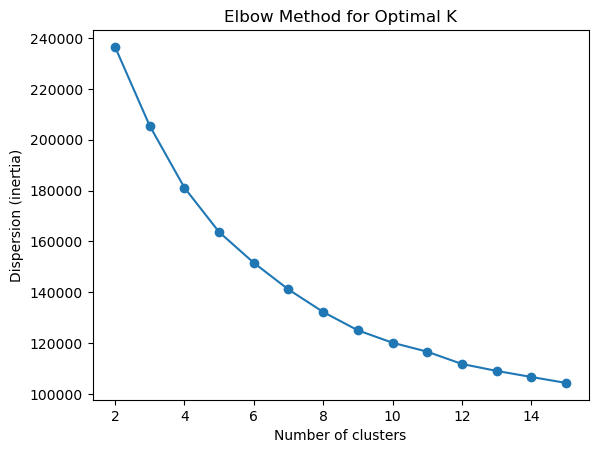

In [11]:
plot_elbow(X_scaled_perc, k_range= 15)

The Elbow Method evaluates the **inertia** to measure cluster compactness. 
As observed in the plot, the inertia decreases smoothly **without** an "elbow" point. This indicates that while the variance continues to drop as K increases, the marginal gain diminishes after the mid-range values.

With all this information, theoretically, the "best" numbers of $K$ would maybe be between 8-10.

##### **2.2.3. Silhouette Score**

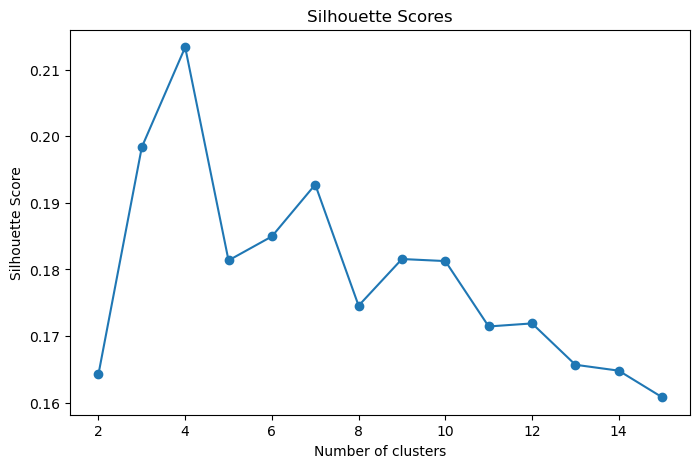

Evaluating Silhouette Scores:
k=6 | silhouette=0.1839
k=7 | silhouette=0.1909
k=8 | silhouette=0.1724
k=9 | silhouette=0.1790


In [12]:
plot_silhouette_kmeans(X_scaled_perc)
print_silhouette_scores(X_scaled_perc, k_values= [6,7,8,9])

The Silhouette Score measures **cluster cohesion**. The plot demonstrates a mathematical peak at lower values (e.g., K=4). However, we decided that selecting K=4 would result in **under-fitting**, as it would not be appropriate to divide the whole dataset in just 2 groups.



### **2.3. K-Means Algorithm**

##### **2.3.1. How it Works**

The first algorithm we used was **K-Means**. Mathematically, it starts by defining $K$ centroids (the central points) in the data space. Then, assigns every customer to the centroid that most closely matches their unique purchasing habits. Through continuous iteration, the algorithm refines these groups until it achieves **maximum similarity inside** each cluster and **maximum variance between** clusters.

By setting the model to **$K=7$**, as defined before, the algorithm identifies nine different profiles that exist in the dataset.

In [14]:
apply_kmeans_perc(X_scaled_perc, dataset_perc, X_perc, k = 7)

Customer Distribution for K=7:
cluster_kmeans_perc
0    5730
1    9778
2    2977
3    5728
4    2281
5    2373
6    1756
Name: count, dtype: int64


,n_clusters,7
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [16]:
cluster_groupby(X_perc, cluster_kmeans= 'cluster_kmeans_perc', method= 'mean')

Grouped by mean


cluster_kmeans_perc,0,1,2,3,4,5,6
customer_age,54.310297,56.516159,56.985556,57.618191,61.228847,57.111252,58.551822
number_complaints,0.767190,0.496318,1.047699,0.645775,2.715476,0.878213,0.821754
kids_home,0.700175,0.817243,0.253275,1.044867,1.146427,3.894227,0.784738
teens_home,0.573473,0.826856,0.307020,0.880412,1.059185,3.071218,0.752847
percentage_of_products_bought_promotion,0.734515,0.183479,0.258678,0.132800,0.288398,0.206248,0.427844
perc_spend_vegetables,0.023018,0.026229,0.008098,0.126310,0.025124,0.023135,0.054112
perc_spend_meat_fish,0.064879,0.055580,0.075900,0.014790,0.064820,0.078517,0.186588
perc_spend_tech_entertainment,0.074312,0.079510,0.499457,0.110151,0.100144,0.152450,0.158281
perc_spend_hygiene,0.029528,0.032324,0.011452,0.093885,0.032166,0.026197,0.083560


In [21]:
numeric_cols_perc = dataset_perc.select_dtypes(include='number')

cluster_groupby(numeric_cols_perc, cluster_kmeans= 'cluster_kmeans_perc', method= 'mean')

Grouped by mean


cluster_kmeans_perc,0,1,2,3,4,5,6
customer_age,54.310297,56.516159,56.985556,57.618191,61.228847,57.111252,58.551822
kids_home,0.700175,0.817243,0.253275,1.044867,1.146427,3.894227,0.784738
teens_home,0.573473,0.826856,0.307020,0.880412,1.059185,3.071218,0.752847
year_first_transaction,2015.317452,2014.209041,2017.007054,2015.521648,2014.018851,2012.944796,2014.525626
distinct_stores_visited,4.143106,3.083759,1.520658,3.397521,3.409031,3.246523,3.582574
number_complaints,0.767190,0.496318,1.047699,0.645775,2.715476,0.878213,0.821754
typical_hour,14.375567,11.652076,17.357743,12.346194,13.384919,10.129372,12.756264
lifetime_total_distinct_products,138.827225,173.263858,111.587504,103.054295,168.788251,298.325748,152.160592
percentage_of_products_bought_promotion,0.734515,0.183479,0.258678,0.132800,0.288398,0.206248,0.427844
lifetime_spend_groceries,18920.931588,21451.460217,8025.873362,9812.501397,21723.591407,25037.279393,4024.195900


### **2.4. Hierarchical Clustering**

#### **2.4.1. Dedrogram**

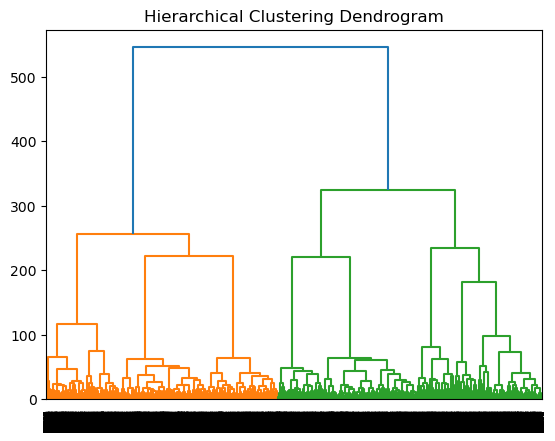

In [ ]:
dendrogram_visualization(X_scaled_perc)

#### **2.4.2 Silhouette score**

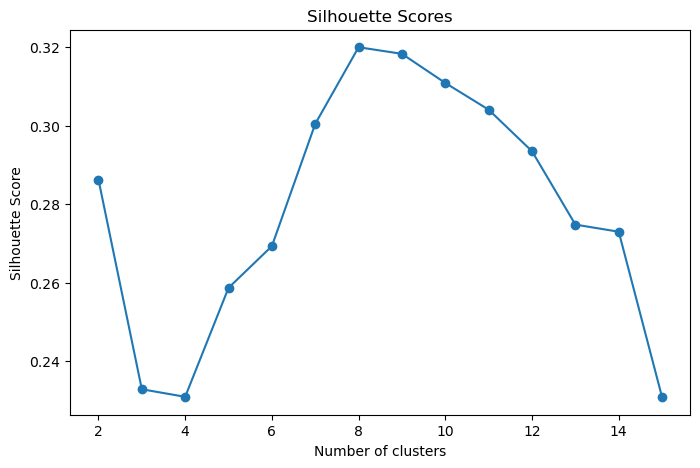

In [ ]:
plot_silhouette_hierarchical(X_scaled_perc)

In [22]:
apply_hierarchical_perc(X_scaled_perc, dataset_perc, X_perc, k = 7)

Customer Distribution for K=7:
cluster_agglomerative_perc
0    6669
1    7877
2    4094
3    2811
4    7246
5    1277
6     649
Name: count, dtype: int64


,n_clusters,7
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


### **2.5. K-Means vs Hierarchical Clustering Validation Matrix**

In order to validate the robustness of the segmentation results, we compare the clusters obtained with K-Means against the clusters obtained with Agglomerative Hierarchical Clustering.
The objective is not necessarily for the values to appear on the main diagonal, because cluster labels are arbitrary. For example, K-Means cluster 0 does not need to correspond to Hierarchical cluster 0. 

**What matters is whether each K-Means cluster maps mostly to one specific Hierarchical cluster.**

If most customers from a K-Means cluster are concentrated in a single Hierarchical cluster, this suggests that both algorithms are identifying a similar underlying structure in the data. On the other hand, if one K-Means cluster is spread across many Hierarchical clusters, this indicates weaker agreement and suggests that the segmentation may be less stable.



In [23]:
pd.DataFrame(
    confusion_matrix(
        dataset_perc['cluster_kmeans_perc'],
        dataset_perc['cluster_agglomerative_perc']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 7)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 7)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster
K-Means 0 Cluster,2,315,112,18,5270,9,4
K-Means 1 Cluster,1085,6166,1500,74,952,0,1
K-Means 2 Cluster,3,264,13,2672,20,3,2
K-Means 3 Cluster,5548,30,0,0,36,113,1
K-Means 4 Cluster,9,616,109,44,378,1099,26
K-Means 5 Cluster,8,3,2308,0,7,46,1
K-Means 6 Cluster,14,483,52,3,583,7,614


The **Adjusted Rand Index** was used to quantify the agreement between the K-Means and Agglomerative Clustering solutions. Unlike a simple comparison of cluster labels, ARI evaluates whether pairs of observations are assigned consistently across both methods.


**Note:**

1 -> Perfect agreement

0.40-0.80 -> Moderate to strong agreement

0-0.40 -> Weak agrerement

0 -> Agreement is approximately what would be expected by chance

< 0 -> Worse agreement than expected by chance.

#### **2.5.1 Adjusted Rand Index**

In [24]:
ari = adjusted_rand_score(
    dataset_perc['cluster_kmeans_perc'],
    dataset_perc['cluster_agglomerative_perc']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.538


### **7. Clustering Visualization**

#### **7.1 t-Distributed Stochastic Neighbor Embedding or TSNE**

In [25]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_perc)


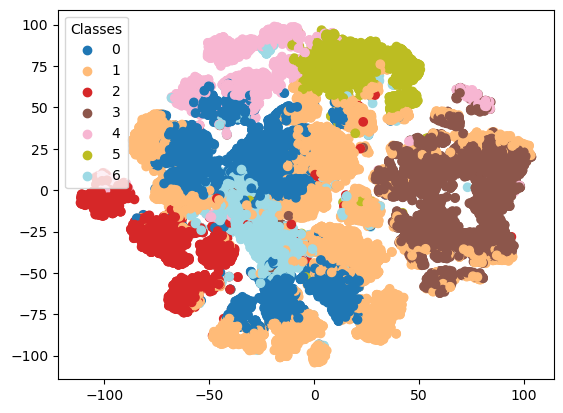

In [27]:
visualize_dimensionality_reduction(tsne_transformation, dataset_perc['cluster_kmeans_perc'])    


#### **7.2 Uniform Manifold Approximation and Projection**

In [28]:
umap = UMAP(n_neighbors=50, random_state=0)

umap_transformation = umap.fit_transform(X_scaled_perc)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:83: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


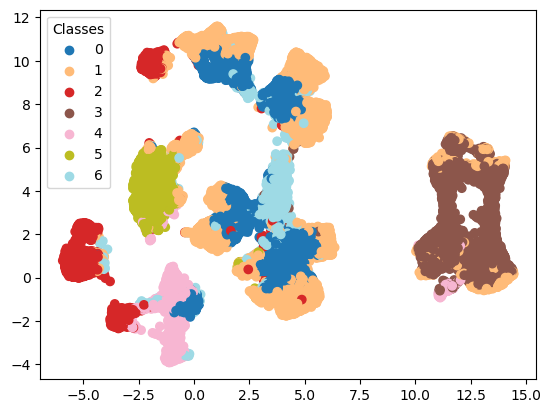

In [29]:
visualize_dimensionality_reduction(umap_transformation, dataset_perc['cluster_kmeans_perc'])

**Important: Before we assigned any names to each cluster, we first performed clustering with lifetime spend values and found out that it was better, therefore the cluster names will be define below in the notebook.**

## **3. Clustering with lifetime spend values**

In [30]:
dataset_lifetime = modelling_df.copy()

In [52]:
features_lifetime = [
    'customer_age',
    'kids_home',
    'teens_home',
    'number_complaints',
    'percentage_of_products_bought_promotion',

    'lifetime_spend_groceries',
    'lifetime_spend_vegetables',
    'lifetime_spend_meat_fish', 
    'lifetime_spend_electronics',
    'lifetime_spend_videogames',
    'lifetime_spend_hygiene',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_petfood'
]

X_lifetime_model = dataset_lifetime[features_lifetime].copy()  
X_lifetime_original = dataset_lifetime[features_lifetime].copy()

In [53]:
X_scaled_lifetime = scaling(X_lifetime_model) #Standard Scaler

X_scaled_lifetime = pd.DataFrame(
    X_scaled_lifetime,
    columns=X_lifetime_model.columns,
    index=X_lifetime_model.index
)

### **3.1 Determining the Optimal Number of Clusters (K)**

#### **3.1.1. Elbow Method**

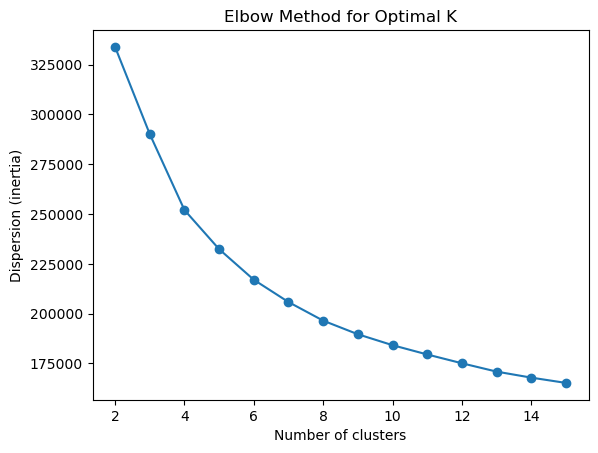

In [54]:
plot_elbow(X_scaled_lifetime, k_range= 15)

#### **3.1.2 Silhouette Score**

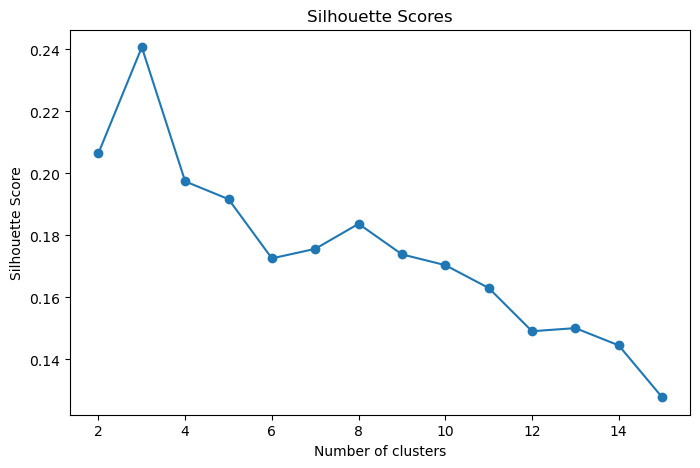

Evaluating Silhouette Scores:
k=7 | silhouette=0.1748
k=8 | silhouette=0.1818
k=9 | silhouette=0.1737
k=10 | silhouette=0.1705


In [55]:
plot_silhouette_kmeans(X_scaled_lifetime)
print_silhouette_scores(X_scaled_lifetime, k_values= [7,8,9,10])

In [56]:
X_scaled_lifetime.columns

Index(['customer_age', 'kids_home', 'teens_home', 'number_complaints',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics', 'lifetime_spend_videogames',
       'lifetime_spend_hygiene', 'lifetime_spend_alcohol_drinks',
       'lifetime_spend_petfood'],
      dtype='object')

### **3.2 K-Means Algorithm**

In [60]:
apply_kmeans_lifetime(X_scaled_lifetime, dataset_lifetime, X_lifetime_original, k = 8)

Customer Distribution for K=8:
cluster_kmeans_lifetime
0    7349
1    3237
2    3197
3    1394
4    5642
5    3741
6    3008
7    3055
Name: count, dtype: int64


,n_clusters,8
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [61]:
cluster_groupby(X_lifetime_original,cluster_kmeans= 'cluster_kmeans_lifetime', method= 'mean')

Grouped by mean


cluster_kmeans_lifetime,0,1,2,3,4,5,6,7
customer_age,56.228466,56.881372,57.204254,65.769010,54.172988,57.750334,57.419880,57.342717
kids_home,0.679956,0.252703,1.046606,1.246055,0.648706,1.036354,1.032912,3.415385
teens_home,0.729623,0.315107,0.863309,1.249641,0.528181,0.902433,0.876330,2.775123
number_complaints,0.471357,1.068582,0.530810,3.118364,0.772598,0.761026,0.983045,0.870049
percentage_of_products_bought_promotion,0.181494,0.256343,0.156734,0.312459,0.721181,0.107225,0.411536,0.204252
lifetime_spend_groceries,15801.450537,8704.699413,12176.303722,17566.884505,11870.253633,10686.448009,41127.381649,24851.333552
lifetime_spend_vegetables,486.613281,178.604263,1474.280263,528.773314,420.715881,1992.394547,362.800532,818.773813
lifetime_spend_meat_fish,1385.495442,1740.486871,284.327807,1676.621234,1145.305920,170.067362,2020.615691,2777.166612
lifetime_spend_electronics,1340.640767,10060.016682,832.360651,2023.294118,1074.195853,1945.148623,3595.744348,4944.256956
lifetime_spend_videogames,213.531501,1522.789002,147.874570,260.068867,232.572315,228.767175,341.546875,410.614075


In [62]:
numeric_cols_lifetime = dataset_lifetime.select_dtypes(include='number').drop(['latitude', 'longitude', 'is_customer_outlier','is_dense_geo_area'], axis = 1)

cluster_groupby(numeric_cols_lifetime, cluster_kmeans= 'cluster_kmeans_lifetime', method= 'mean')

Grouped by mean


cluster_kmeans_lifetime,0,1,2,3,4,5,6,7
customer_age,56.228466,56.881372,57.204254,65.769010,54.172988,57.750334,57.419880,57.342717
kids_home,0.679956,0.252703,1.046606,1.246055,0.648706,1.036354,1.032912,3.415385
teens_home,0.729623,0.315107,0.863309,1.249641,0.528181,0.902433,0.876330,2.775123
year_first_transaction,2014.372840,2017.008341,2016.241789,2013.766141,2015.910493,2014.716653,2012.734707,2012.936170
distinct_stores_visited,2.959995,1.483163,3.561464,3.182209,4.196384,3.225341,3.872673,3.235679
number_complaints,0.471357,1.068582,0.530810,3.118364,0.772598,0.761026,0.983045,0.870049
typical_hour,11.167370,17.389558,10.759775,13.418938,14.411379,13.890938,13.278923,10.142390
lifetime_total_distinct_products,160.679412,109.429410,122.661871,152.859397,112.654378,85.161989,251.830452,301.239607
percentage_of_products_bought_promotion,0.181494,0.256343,0.156734,0.312459,0.721181,0.107225,0.411536,0.204252
lifetime_spend_groceries,15801.450537,8704.699413,12176.303722,17566.884505,11870.253633,10686.448009,41127.381649,24851.333552


In [72]:
cluster_names = {
    0: "Regular Cutomers",
    1: "Gamers",
    2: "Clean & Green",
    3: 'Senior Karens',
    4: "Promotion Lovers",
    5: "Low-Value Occasional Customers",
    6: "High-Value Customers<",
    7: "Large Families"
}


dataset_lifetime['cluster_name'] = dataset_lifetime['cluster_kmeans_lifetime'].map(cluster_names)
dataset_lifetime.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,year_first_transaction,distinct_stores_visited,number_complaints,typical_hour,...,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier,is_dense_geo_area,cluster_kmeans_lifetime,cluster_agglomerative_lifetime,cluster_name
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2020,3,1,10,...,0.631038,0.009521,0.029693,38.794428,-9.215739,0,0,4,1,Promotion Lovers
4,Glenda Bauman,female,51,Bsc,1,0,2013,2,0,10,...,0.676815,0.004695,0.092918,38.751711,-9.179611,0,0,2,6,Clean & Green
5,Antonio Campbell,male,55,Msc,0,0,2005,2,1,11,...,0.797929,0.007589,0.032607,38.780678,-9.160656,0,0,0,5,Regular Cutomers
7,John Kelling,male,44,Unknown,0,0,2021,1,2,18,...,0.501137,0.075776,0.032437,38.739548,-9.148679,0,0,1,3,Gamers
8,Arthur Dematteo,male,57,Unknown,0,0,2021,1,3,17,...,0.356127,0.027833,0.011513,38.733071,-9.188188,0,0,1,3,Gamers


### **3.3. Hierarchical Algorithm**

In [ ]:
dendrogram_visualization(X_scaled_lifetime)

In [ ]:
plot_silhouette_hierarchical(X_scaled_lifetime)

In [63]:
apply_hierarchical_lifetime(X_scaled_lifetime, dataset_lifetime, X_lifetime_original, k = 7)

Customer Distribution for K=7:
cluster_agglomerative_lifetime
0    4179
1    6323
2    3517
3    3550
4    3558
5    6236
6    3260
Name: count, dtype: int64


,n_clusters,7
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


### **6. K-Means vs Hierarchical Clustering Validation Matrix**

In [65]:
pd.DataFrame(
    confusion_matrix(
        dataset_lifetime['cluster_kmeans_lifetime'],
        dataset_lifetime['cluster_agglomerative_lifetime']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 8)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 8)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster
K-Means 0 Cluster,449,1130,92,128,2,5520,28,0
K-Means 1 Cluster,2,44,7,3183,0,1,0,0
K-Means 2 Cluster,30,1,0,2,96,50,3018,0
K-Means 3 Cluster,947,238,94,28,1,82,4,0
K-Means 4 Cluster,344,4710,5,100,1,481,1,0
K-Means 5 Cluster,8,18,2,6,3458,41,208,0
K-Means 6 Cluster,2374,181,293,101,0,58,1,0
K-Means 7 Cluster,25,1,3024,2,0,3,0,0


#### **6.1. Adjusted Rand Index**

In [66]:
ari = adjusted_rand_score(
    dataset_lifetime['cluster_kmeans_lifetime'],
    dataset_lifetime['cluster_agglomerative_lifetime']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.661


### **7. Clustering Visualization**

#### **7.1. TSNE**

In [67]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_lifetime)

c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:83: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


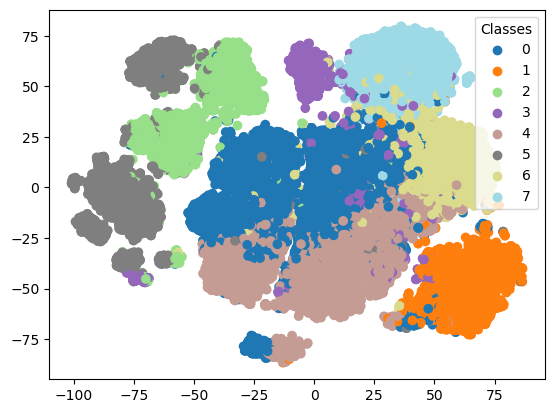

In [68]:
visualize_dimensionality_reduction(tsne_transformation, dataset_lifetime['cluster_kmeans_lifetime'])    


#### **7.1. UMAP**

In [69]:
umap = UMAP(n_neighbors=50, random_state=0)



umap_transformation = umap.fit_transform(X_scaled_lifetime)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:83: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


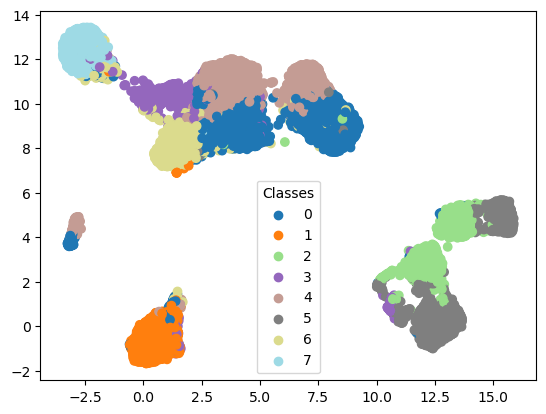

In [70]:
visualize_dimensionality_reduction(umap_transformation, dataset_lifetime['cluster_kmeans_lifetime'])

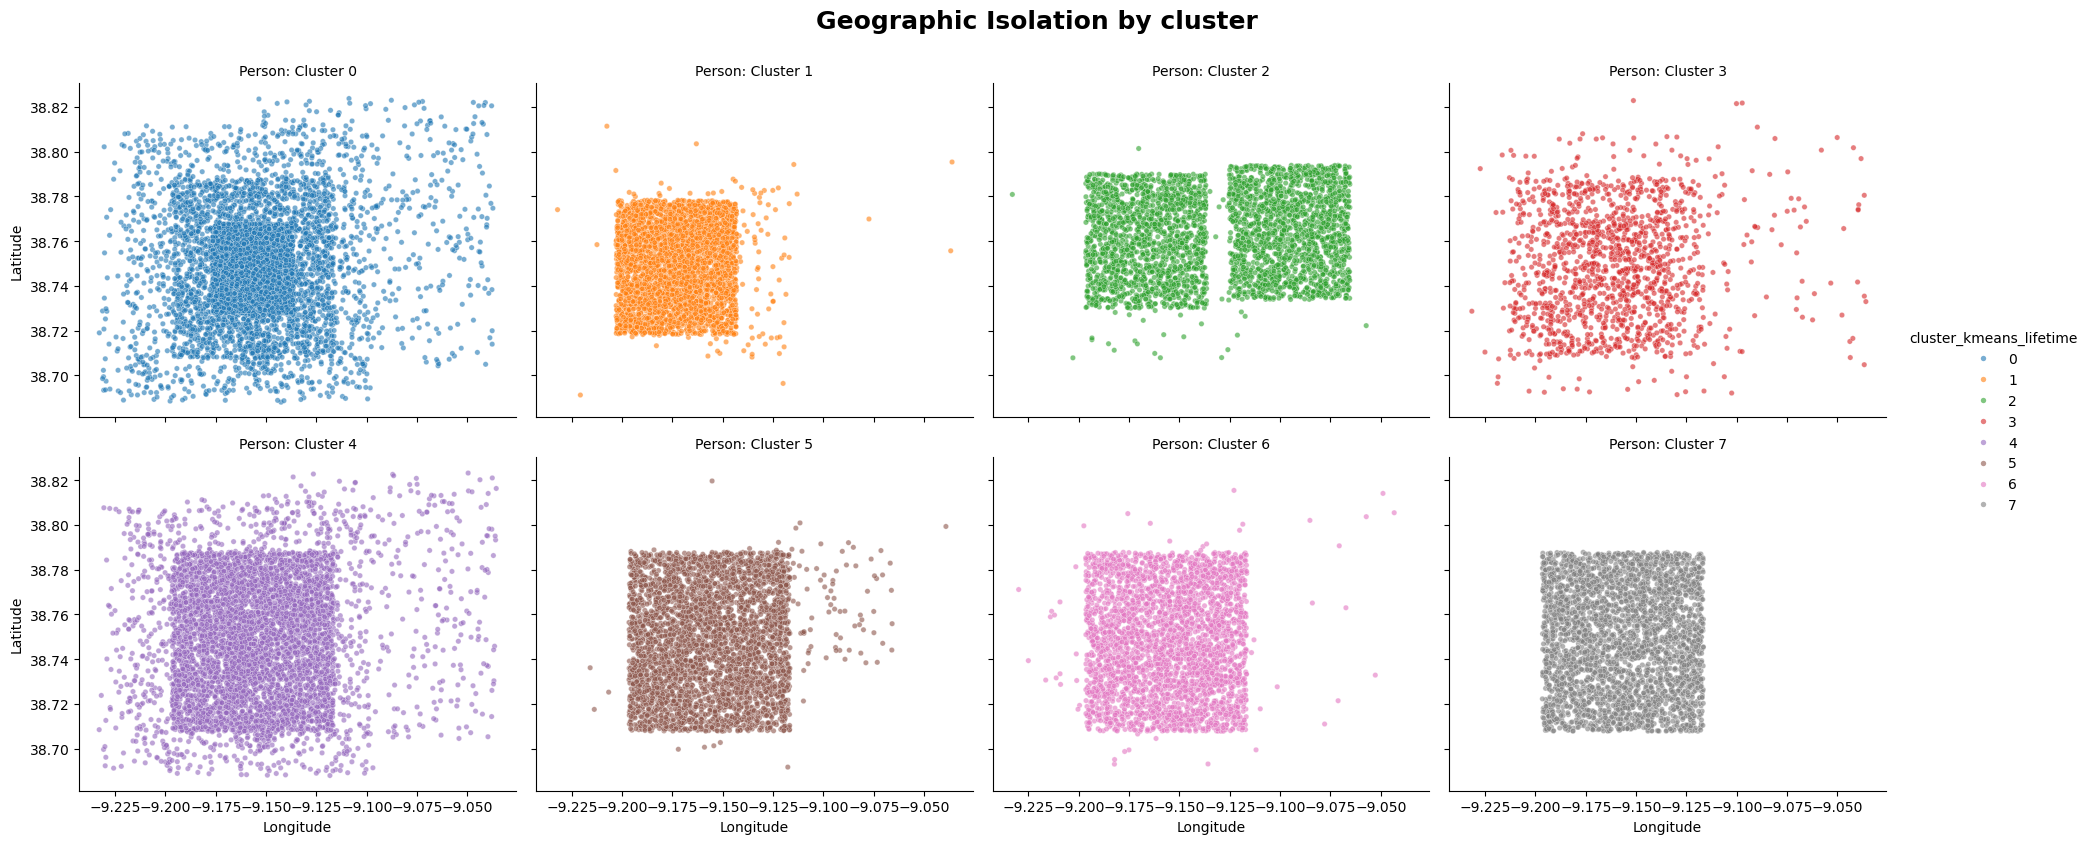

In [71]:
# Using relplot to create a grid: one map per cluster
g = sns.relplot(
    data=dataset_lifetime,
    x='longitude',
    y='latitude',
    col='cluster_kmeans_lifetime', # This splits the data into separate plots!
    col_wrap=4,           # Defines 4 maps per row
    hue='cluster_kmeans_lifetime',
    palette='tab10',
    s=15,                 # Dot size
    alpha=0.6,            # Transparency
    height=4,             # Height of each individual map
    aspect=1.2            # Width ratio
)

# Formatting for the university report
g.fig.suptitle('Geographic Isolation by cluster', y=1.05, fontsize=18, fontweight='bold')
g.set_axis_labels('Longitude', 'Latitude')
g.set_titles('Person: Cluster {col_name}') # Names each subplot automatically

plt.show()

## **Final Segmentation Dataset**

After selecting the final clustering approach, the predefined dense geographic segment is combined with the K-Means clusters obtained from the remaining customers.

In [73]:
geo_cluster_df['cluster_kmeans_lifetime'] = 8
geo_cluster_df['cluster_name'] = 'Young Karens'

final_clustered_dataset = pd.concat(
    [dataset_lifetime, geo_cluster_df],
    axis=0
).sort_index()

final_clustered_dataset['cluster_kmeans_lifetime'].value_counts().sort_index()

cluster_kmeans_lifetime
0    7349
1    3237
2    3197
3    1394
4    5642
5    3741
6    3008
7    3055
8    2415
Name: count, dtype: int64

In [ ]:
final_clustered_dataset = final_clustered_dataset.reset_index()

In [74]:
print(final_clustered_dataset["cluster_kmeans_lifetime"].value_counts().sort_index())
print(final_clustered_dataset["cluster_name"].isna().sum())
print(final_clustered_dataset["customer_id"].nunique())
print(dataset["customer_id"].nunique())

cluster_kmeans_lifetime
0    7349
1    3237
2    3197
3    1394
4    5642
5    3741
6    3008
7    3055
8    2415
Name: count, dtype: int64
0


KeyError: 'customer_id'

In [ ]:
dataset_export = final_clustered_dataset

dataset_export.columns

In [ ]:
customer_clusters = dataset_export[['customer_id', 'cluster_kmeans_lifetime', 'cluster_name']].copy()

customer_clusters = customer_clusters.rename(
    columns={'cluster_kmeans_lifetime': 'cluster_kmeans'}
)

customer_clusters.to_csv("../data/customer_final_clusters.csv", index=False)

customer_clusters.head()

KeyError: "['cluster_name'] not in index"